# SELFIES Predict

In [1]:
%pip install -qq --ignore-requires-python --no-deps 'graphies[predict] @ git+https://github.com/lukasmki/graphies.git'
%pip install -qq pydantic networkx datasets polars torch

import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")
else:
    print(
        "CUDA is not available. Please ensure you have selected a GPU runtime in 'Runtime > Change runtime type'."
    )

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
Device name: NVIDIA A100-SXM4-40GB


## Setup Data Sources

In [2]:
!mkdir -p selfies-data
!wget -nv https://raw.githubusercontent.com/lukasmki/graphies-applications/refs/heads/main/grammars/selfies.json -O selfies-data/selfies.json

from pathlib import Path

GRAMMAR_PATH = next(Path().glob("selfies-data/*.json"))

2026-04-12 20:44:32 URL:https://raw.githubusercontent.com/lukasmki/graphies-applications/refs/heads/main/grammars/selfies.json [3047/3047] -> "selfies-data/selfies.json" [1]


In [3]:
%pip install -qq selfies

import selfies as sf
from datasets import load_dataset

sf.set_semantic_constraints(
    {  # disable degree constriaints
        k: 24 for k, _ in sf.get_semantic_constraints().items()
    }
)


def transform_batch(batch: dict):
    selfies = []
    for smi in batch["canonical_smiles"]:
        try:
            selfies.append(sf.encoder(smi, strict=False))
        except Exception:
            selfies.append(None)

    return {"graphies": selfies}


hf_dataset = load_dataset("lukaskim/ChEMBL-36", "molecules", split="train")

hf_dataset = hf_dataset.map(
    transform_batch,
    batched=True,
    batch_size=1000,
    num_proc=4,
    desc="Encoding SELFIES",
)

hf_dataset = hf_dataset.filter(
    lambda x: x["graphies"] is not None,
    num_proc=4,
    desc="Filtering nulls",
)

## Setup Data Loaders

In [4]:
from torch.utils.data import DataLoader, random_split
from graphies.predict import HFGraphiesDataset, GraphiesTokenizer

tokenizer = GraphiesTokenizer(GRAMMAR_PATH)
dataset = HFGraphiesDataset(
    hf_dataset, column="graphies", tokenizer=tokenizer, split=None
)

trn, tst = random_split(dataset, [0.9, 0.1])
torch.save(
    {"trn_indices": trn.indices, "tst_indices": tst.indices}, "selfies-data/split.pt"
)
trn_loader = DataLoader(
    dataset=trn,
    batch_size=256,
    shuffle=True,
    collate_fn=tokenizer.collate,
)
tst_loader = DataLoader(
    dataset=tst,
    batch_size=256,
    shuffle=False,
    collate_fn=tokenizer.collate,
)

## Trainer

In [5]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from graphies.predict import GraphiesTrainer
from graphies.predict.models import GRU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GRU(vocab_size=tokenizer.vocab_size)
optimizer = Adam(params=model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.1)

# include kwargs for classes to restart from checkpoitn
checkpoint = {
    "model_kwargs": {"vocab_size": tokenizer.vocab_size},
    "optimizer_kwargs": {"lr": 1e-3},
    "scheduler_kwargs": {"mode": "min", "patience": 3, "factor": 0.1},
}
trainer = GraphiesTrainer(model, optimizer, scheduler, device, checkpoint)

In [6]:
trainer.train(
    train=trn_loader,
    epochs=1,
    test=tst_loader,
    test_interval=1,
    log="selfies-data/log.csv",
    log_interval=1,
    checkpoint="selfies-data/chk.pt",
    checkpoint_interval=1,
)
trainer.save_model("selfies-data/model.pt")

Test 1: 100%|██████████| 1116/1116 [01:51<00:00, 10.03it/s, loss=0.7592]


In [7]:
# export to google drive
from google.colab import drive

drive.mount("/content/drive")
!zip -r selfies-data.zip selfies-data/
!cp selfies-data.zip '/content/drive/MyDrive/'

Mounted at /content/drive
  adding: selfies-data/ (stored 0%)
  adding: selfies-data/log.csv (deflated 20%)
  adding: selfies-data/model.pt (deflated 7%)
  adding: selfies-data/split.pt (deflated 29%)
  adding: selfies-data/0-chk.pt (deflated 11%)
  adding: selfies-data/selfies.json (deflated 82%)


# Run Inference

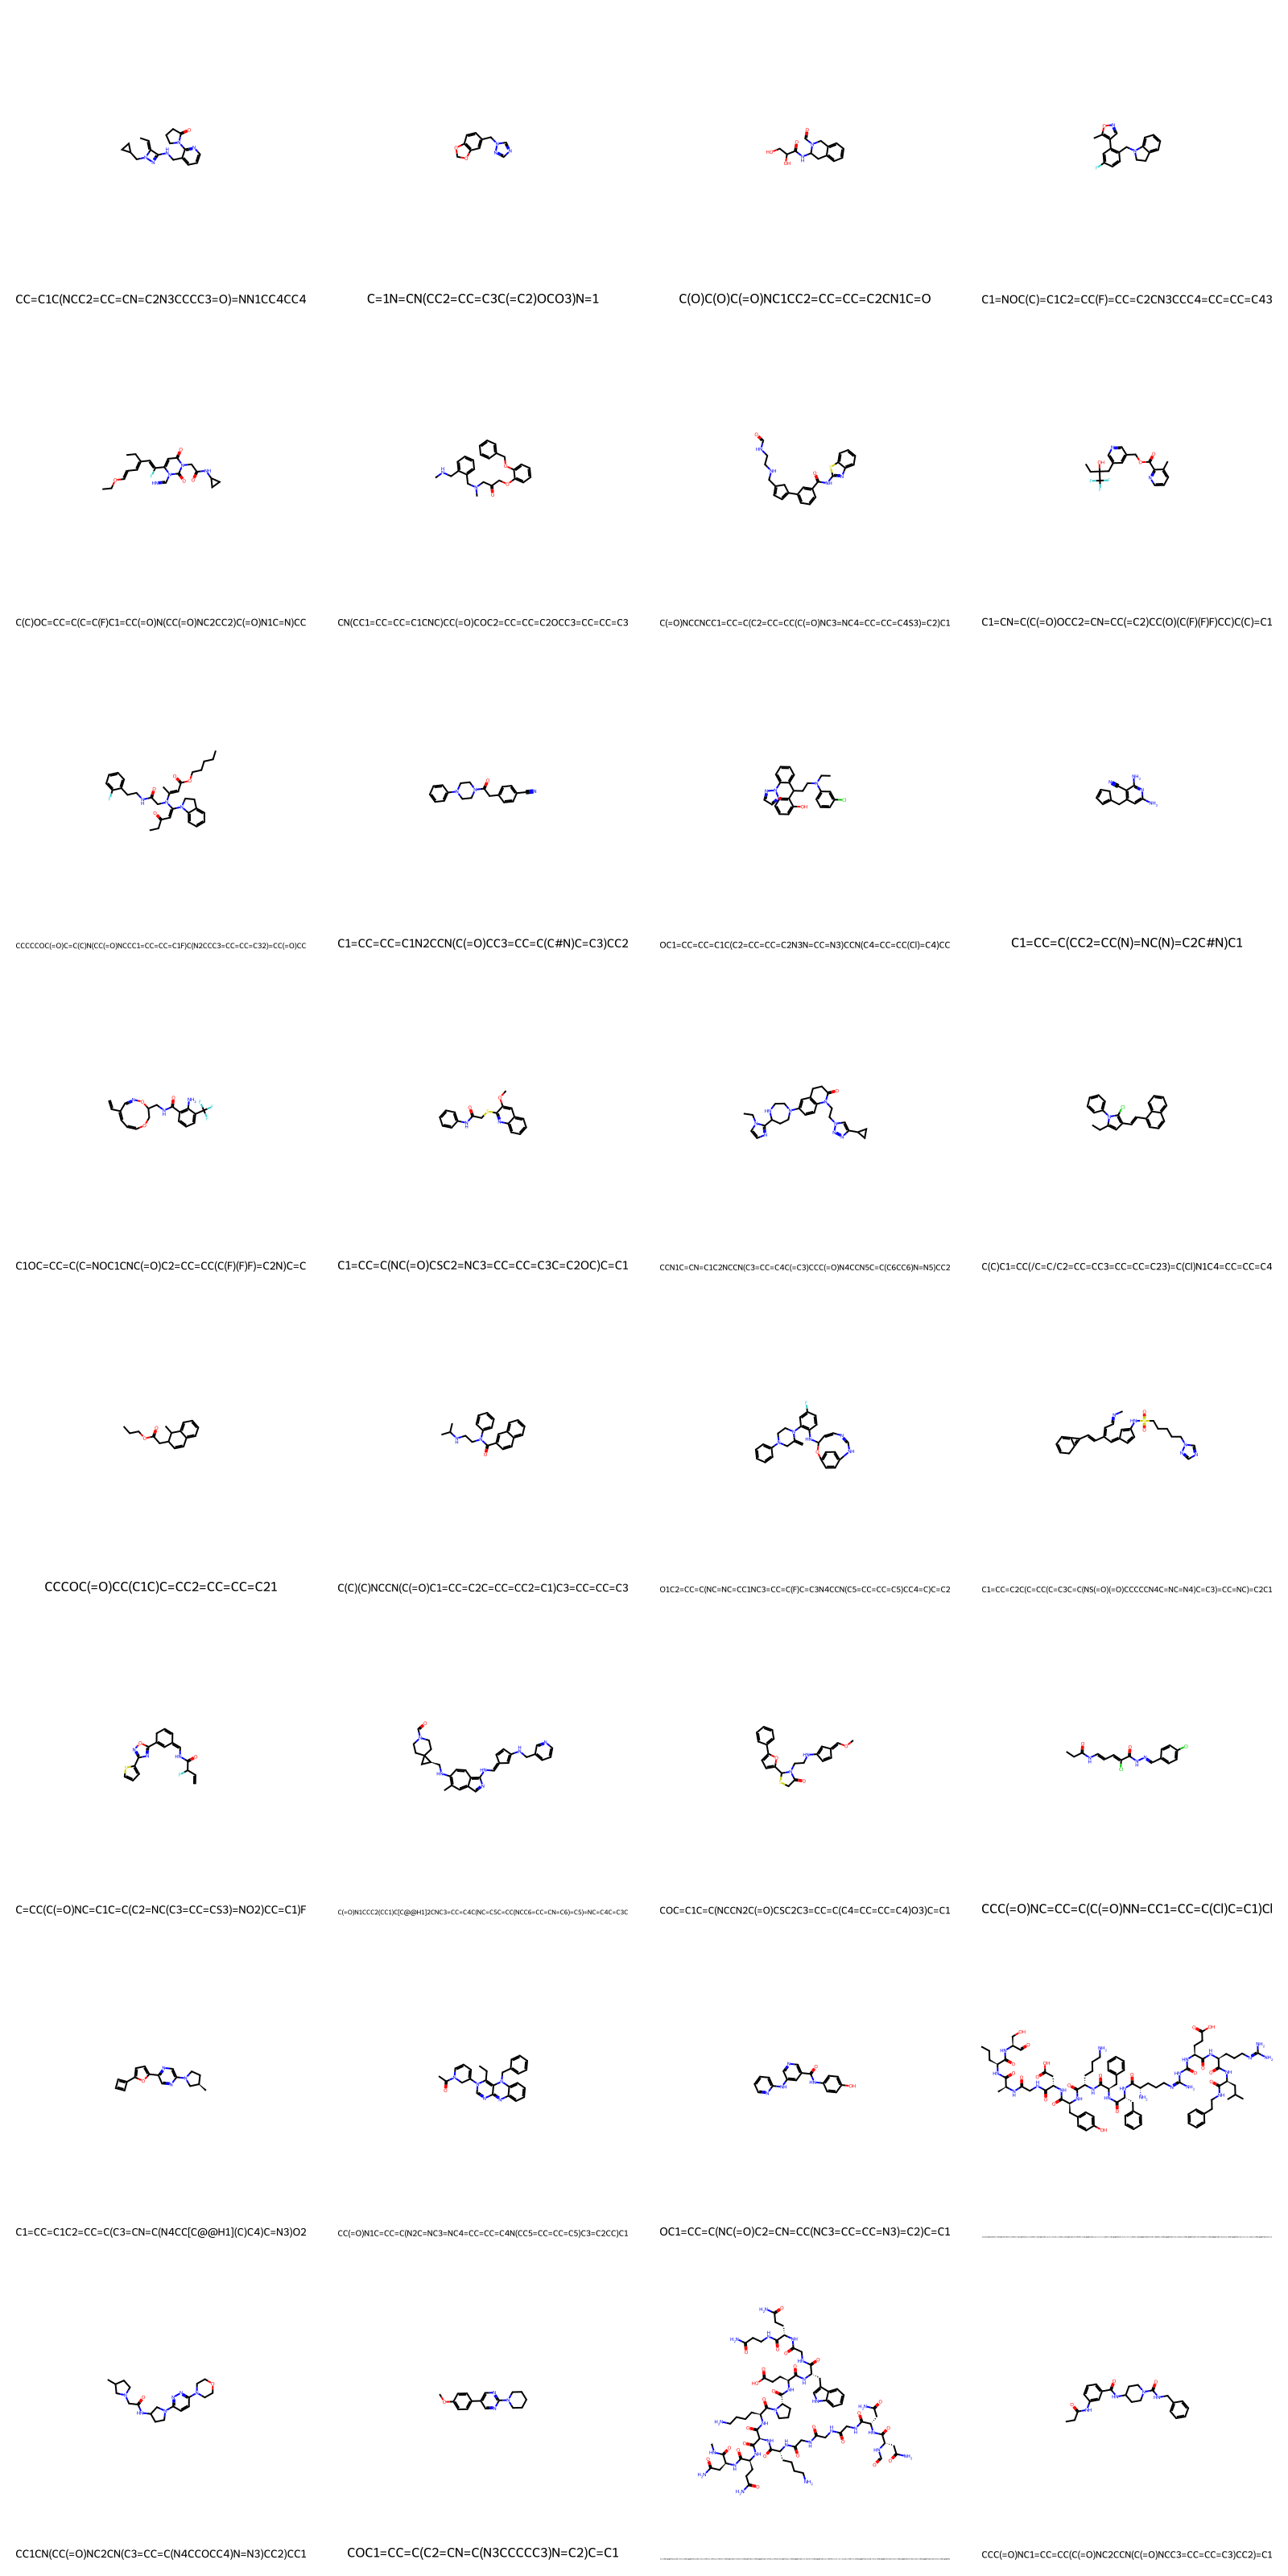

In [9]:
%pip install -qq rdkit

import selfies as sf
from rdkit import Chem
from IPython.display import display
from graphies.predict import GraphiesModel

sf.set_semantic_constraints("default")

model = GraphiesModel.from_checkpoint(
    checkpoint="selfies-data/model.pt",
    tokenizer=tokenizer,
    model_cls=GRU,
    device=device,
)

legends = []
mols = []
sequences = model.generate(num=32, temperature=0.9, top_p=0.95, max_len=200)
for i, sequence in enumerate(sequences):
    graphies = tokenizer.strip(sequence)  # strip [BEGIN] and [END] tags
    smiles = sf.decoder(graphies)

    mols.append(Chem.MolFromSmiles(smiles))
    legends.append(smiles)

img = Chem.Draw.MolsToGridImage(
    mols, molsPerRow=4, legends=legends, subImgSize=(400, 400)
)
display(img)